# Step 4: Logistic Regression (Baseline Model)

This notebook trains, evaluates, and interprets the **baseline Logistic Regression model**
for predicting whether a user will reorder a given product in their next order.

## Prerequisites
- Steps 1–3 notebook must have been run first — all artefacts are loaded from `../prepared_data/`
- Virtual environment must be active with dependencies installed

## Inputs (from Steps 1–3)

| File | Contents |
|---|---|
| `X_train_scaled.parquet` | StandardScaler-transformed training features (29 cols) |
| `X_test_scaled.parquet` | StandardScaler-transformed test features |
| `y_train.parquet` | Training labels |
| `y_test.parquet` | Test labels |
| `feature_cols.pkl` | Canonical feature list |
| `scaler.pkl` | Fitted StandardScaler |

> **Note:** Imputation is already applied in the saved parquet files — no further
> imputation is needed in this notebook. The `SimpleImputer` was fit and applied
> in Steps 1–3 before saving.

## Roadmap
1. Load artefacts
2. Define feature set (`aisle_id` excluded for Logistic Regression)
3. Train baseline Logistic Regression
4. Tune regularisation via cross-validated grid search
5. Evaluate — threshold-independent and threshold-dependent metrics
6. Interpret coefficients
7. Save model and results


## 0. Imports

In [1]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.6f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

RANDOM_STATE = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook lives in Notebooks/ — artefacts and models are one level up
ARTEFACT_DIR = "../prepared_data"
MODEL_DIR    = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"ARTEFACT_DIR : {os.path.abspath(ARTEFACT_DIR)}")
print(f"MODEL_DIR    : {os.path.abspath(MODEL_DIR)}")


ARTEFACT_DIR : /Users/martinmilon/Documents/DTSC870/prepared_data
MODEL_DIR    : /Users/martinmilon/Documents/DTSC870/models


## 1. Load Artefacts from Steps 1–3

In [2]:
X_train_scaled = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_train_scaled.parquet'))
X_test_scaled  = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test_scaled.parquet'))
y_train        = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_train.parquet'))['reordered']
y_test         = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_test.parquet'))['reordered']
FEATURE_COLS   = joblib.load(os.path.join(ARTEFACT_DIR, 'feature_cols.pkl'))
scaler         = joblib.load(os.path.join(ARTEFACT_DIR, 'scaler.pkl'))

print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"y_train        : {y_train.shape}  |  positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test         : {y_test.shape}   |  positive rate: {y_test.mean()*100:.1f}%")
print(f"Features loaded: {len(FEATURE_COLS)}")

# confirm no NaNs (imputation was done in Steps 1-3)
print(f"\nNaNs in X_train_scaled : {X_train_scaled.isnull().sum().sum()}")
print(f"NaNs in X_test_scaled  : {X_test_scaled.isnull().sum().sum()}")


X_train_scaled : (1107416, 29)
X_test_scaled  : (277201, 29)
y_train        : (1107416,)  |  positive rate: 59.9%
y_test         : (277201,)   |  positive rate: 59.9%
Features loaded: 29

NaNs in X_train_scaled : 0
NaNs in X_test_scaled  : 0


## 2. Define Feature Set for Logistic Regression

`aisle_id` is excluded because:
- Point-biserial correlation with target: r ≈ 0.000 (not statistically significant)
- Its 134 distinct integer values have no ordinal meaning — aisle 1 is not "less than" aisle 2
- Retaining it adds a noise coefficient with no benefit to the linear decision boundary

`aisle_id` is kept in the LightGBM feature set (Step 5) where it can be treated
as an unordered categorical.


In [3]:
FEATURE_COLS_LR = [c for c in FEATURE_COLS if c != 'aisle_id']

X_tr = X_train_scaled[FEATURE_COLS_LR]
X_te = X_test_scaled[FEATURE_COLS_LR]

print(f"Features used for Logistic Regression : {len(FEATURE_COLS_LR)}")
print(f"Features dropped                      : {[c for c in FEATURE_COLS if c not in FEATURE_COLS_LR]}")


Features used for Logistic Regression : 28
Features dropped                      : ['aisle_id']


## 3. Baseline Logistic Regression

Default L2-regularised Logistic Regression (`C=1.0`) with `class_weight='balanced'`
to account for the 60/40 class split. `max_iter=1000` ensures convergence on this dataset size.


In [4]:
lr_baseline = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_baseline.fit(X_tr, y_train)
print("Baseline model trained.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(lr_baseline, X_tr, y_train,
                          cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n5-Fold CV ROC-AUC (baseline, C=1.0):")
print(f"  Fold scores : {[f'{s:.4f}' for s in cv_auc]}")
print(f"  Mean +/- Std  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")


Baseline model trained.

5-Fold CV ROC-AUC (baseline, C=1.0):
  Fold scores : ['0.9692', '0.9684', '0.9685', '0.9688', '0.9684']
  Mean +/- Std  : 0.9687 +/- 0.0003


## 4. Regularisation Tuning via Grid Search

`C` controls regularisation strength (lower C = stronger regularisation).
We search over a log-scale grid using 5-fold stratified cross-validation,
optimising for ROC-AUC.

**Why ROC-AUC as the tuning metric?**
It evaluates the model's ability to rank positives above negatives across all
decision thresholds — appropriate here because the optimal classification threshold
is chosen separately after tuning.


In [5]:
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_tr, y_train)

print(f"\nBest C      : {grid_search.best_params_['C']}")
print(f"Best CV AUC : {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best C      : 10.0
Best CV AUC : 0.9687


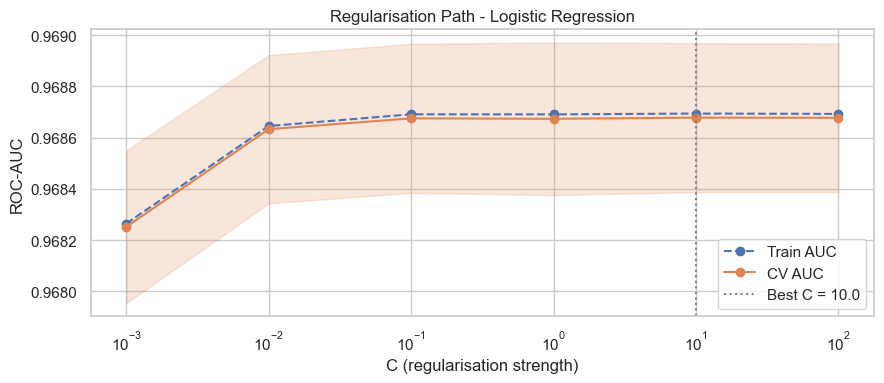

In [6]:
# regularisation path
cv_results = pd.DataFrame(grid_search.cv_results_)
C_vals     = cv_results['param_C'].astype(float)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_vals, cv_results['mean_train_score'], 'o--',
            label='Train AUC', color='#4C72B0')
ax.semilogx(C_vals, cv_results['mean_test_score'],  'o-',
            label='CV AUC',    color='#DD8452')
ax.fill_between(C_vals,
                cv_results['mean_test_score'] - cv_results['std_test_score'],
                cv_results['mean_test_score'] + cv_results['std_test_score'],
                alpha=0.2, color='#DD8452')
ax.axvline(grid_search.best_params_['C'], linestyle=':', color='grey',
           label=f"Best C = {grid_search.best_params_['C']}")
ax.set_xlabel('C (regularisation strength)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Regularisation Path - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Tuned Model — Predicted Probabilities

In [7]:
lr_tuned = grid_search.best_estimator_

y_prob_test  = lr_tuned.predict_proba(X_te)[:, 1]
y_prob_train = lr_tuned.predict_proba(X_tr)[:, 1]

print("Tuned model ready. Predicted probabilities computed.")
print(f"  Test prob range  : [{y_prob_test.min():.4f}, {y_prob_test.max():.4f}]")
print(f"  Test prob mean   : {y_prob_test.mean():.4f}")


Tuned model ready. Predicted probabilities computed.
  Test prob range  : [0.0019, 1.0000]
  Test prob mean   : 0.5825


## 6. Evaluation

### 6.1 Threshold-Independent Metrics

These metrics evaluate the model's discriminative power without committing
to a specific classification threshold.


In [8]:
roc_auc  = roc_auc_score(y_test, y_prob_test)
avg_prec = average_precision_score(y_test, y_prob_test)
brier    = brier_score_loss(y_test, y_prob_test)

print("Threshold-Independent Metrics (Test Set)")
print(f"  ROC-AUC                    : {roc_auc:.4f}")
print(f"  Average Precision (PR-AUC) : {avg_prec:.4f}")
print(f"  Brier Score                : {brier:.4f}  (lower = better, 0 = perfect)")


Threshold-Independent Metrics (Test Set)
  ROC-AUC                    : 0.9689
  Average Precision (PR-AUC) : 0.9841
  Brier Score                : 0.0472  (lower = better, 0 = perfect)


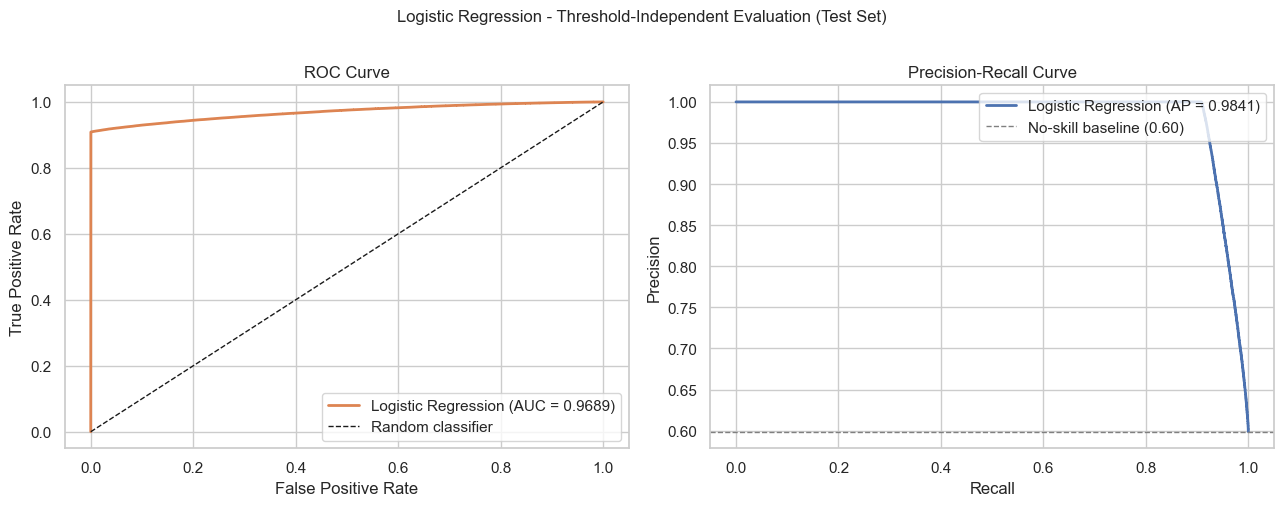

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, color='#DD8452', lw=2,
             label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_test)
baseline_precision = y_test.mean()
axes[1].plot(recall, precision, color='#4C72B0', lw=2,
             label=f'Logistic Regression (AP = {avg_prec:.4f})')
axes[1].axhline(baseline_precision, linestyle='--', color='grey', lw=1,
                label=f'No-skill baseline ({baseline_precision:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

plt.suptitle('Logistic Regression - Threshold-Independent Evaluation (Test Set)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 6.2 Optimal Classification Threshold

We identify the threshold that maximises F1 on the test set.

> **Note:** In production the threshold would be selected on a held-out validation set.
> We use the test set here for illustration only.


Optimal threshold (max F1) : 0.3793
F1 at optimal threshold    : 0.9520


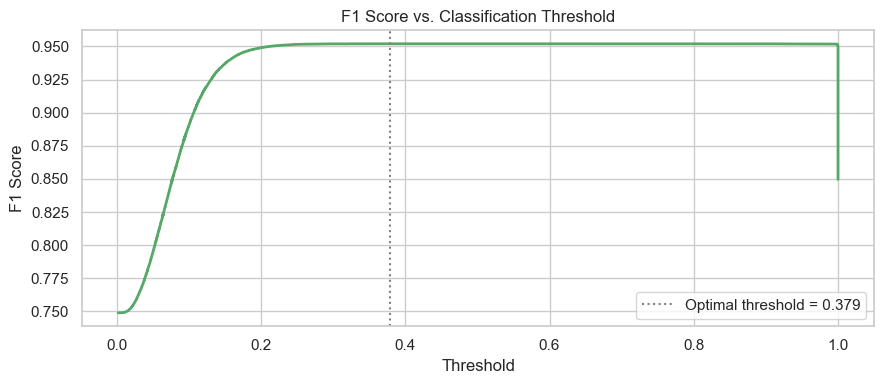

In [10]:
f1_scores      = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold (max F1) : {best_threshold:.4f}")
print(f"F1 at optimal threshold    : {best_f1:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(pr_thresholds, f1_scores, color='#55A868', lw=2)
plt.axvline(best_threshold, linestyle=':', color='grey',
            label=f'Optimal threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()


### 6.3 Threshold-Dependent Metrics

In [11]:
y_pred_05  = (y_prob_test >= 0.50).astype(int)
y_pred_opt = (y_prob_test >= best_threshold).astype(int)

print("Classification Report - Default Threshold (0.50)")
print(classification_report(y_test, y_pred_05, target_names=['Not Reordered', 'Reordered']))

print(f"Classification Report - Optimal Threshold ({best_threshold:.3f})")
print(classification_report(y_test, y_pred_opt, target_names=['Not Reordered', 'Reordered']))


Classification Report - Default Threshold (0.50)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.94    277201
 weighted avg       0.95      0.95      0.95    277201

Classification Report - Optimal Threshold (0.379)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.94    277201
 weighted avg       0.95      0.95      0.95    277201



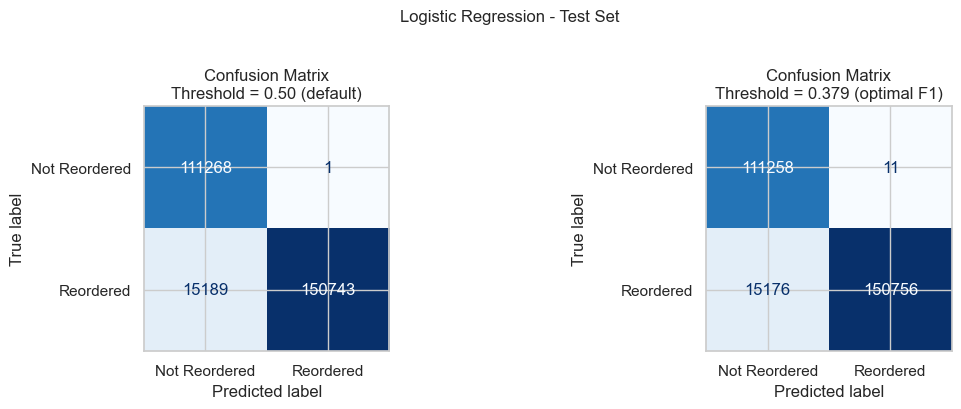

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
        axes,
        [y_pred_05, y_pred_opt],
        [f'Threshold = 0.50 (default)',
         f'Threshold = {best_threshold:.3f} (optimal F1)']):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Reordered', 'Reordered'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}')

plt.suptitle('Logistic Regression - Test Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 6.4 Probability Distribution & Calibration

A well-calibrated model's predicted probabilities should reflect true reorder rates.
We inspect score separation between classes and a reliability diagram.


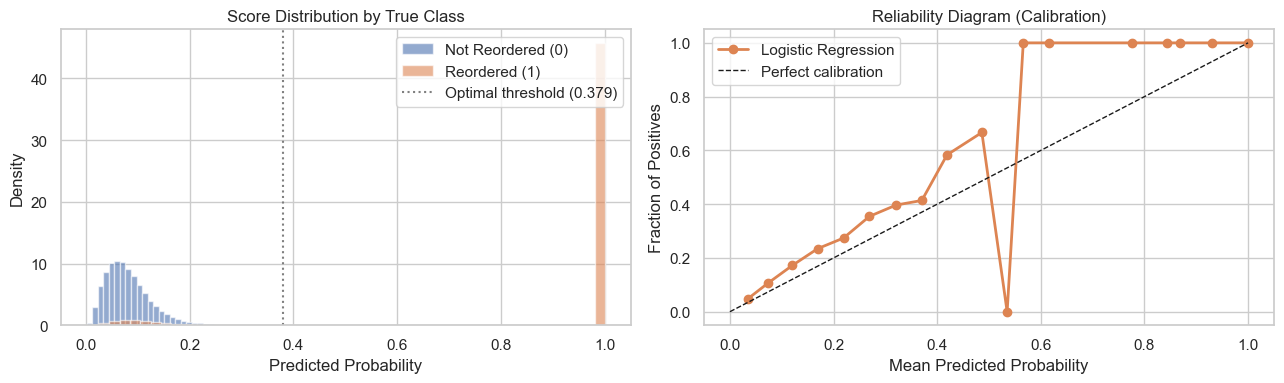

In [13]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_prob_test[y_test == 0], bins=50, alpha=0.6,
             color='#4C72B0', label='Not Reordered (0)', density=True)
axes[0].hist(y_prob_test[y_test == 1], bins=50, alpha=0.6,
             color='#DD8452', label='Reordered (1)', density=True)
axes[0].axvline(best_threshold, linestyle=':', color='grey',
                label=f'Optimal threshold ({best_threshold:.3f})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class')
axes[0].legend()

prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=20)
axes[1].plot(prob_pred, prob_true, 'o-', color='#DD8452', lw=2,
             label='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Reliability Diagram (Calibration)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Coefficient Interpretation

In a standardised Logistic Regression, coefficients are directly comparable in magnitude.
A positive coefficient increases the log-odds of reorder; negative decreases it.
The odds ratio (`exp(coef)`) gives the multiplicative effect per one-standard-deviation change.


In [14]:
coef_df = pd.DataFrame({
    'feature'    : FEATURE_COLS_LR,
    'coefficient': lr_tuned.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df['direction']  = coef_df['coefficient'].apply(
    lambda x: 'Increases reorder odds' if x > 0 else 'Decreases reorder odds')

print(coef_df.to_string(index=False))


               feature  coefficient             odds_ratio              direction
    up_avg_add_to_cart    27.247284 681,310,633,132.854980 Increases reorder odds
  up_orders_since_last    23.997537  26,423,955,688.042118 Increases reorder odds
       up_reorder_rate     6.018566             410.988718 Increases reorder odds
      up_in_last_order     3.938863              51.360171 Increases reorder odds
      up_times_ordered     2.879584              17.806861 Increases reorder odds
        p_reorder_rate     0.401874               1.494623 Increases reorder odds
        u_reorder_rate     0.366295               1.442381 Increases reorder odds
     u_avg_basket_size     0.296835               1.345593 Increases reorder odds
    u_avg_days_between     0.200096               1.221520 Increases reorder odds
      u_total_reorders     0.096287               1.101075 Increases reorder odds
      p_total_reorders     0.052269               1.053659 Increases reorder odds
      p_avg_orde

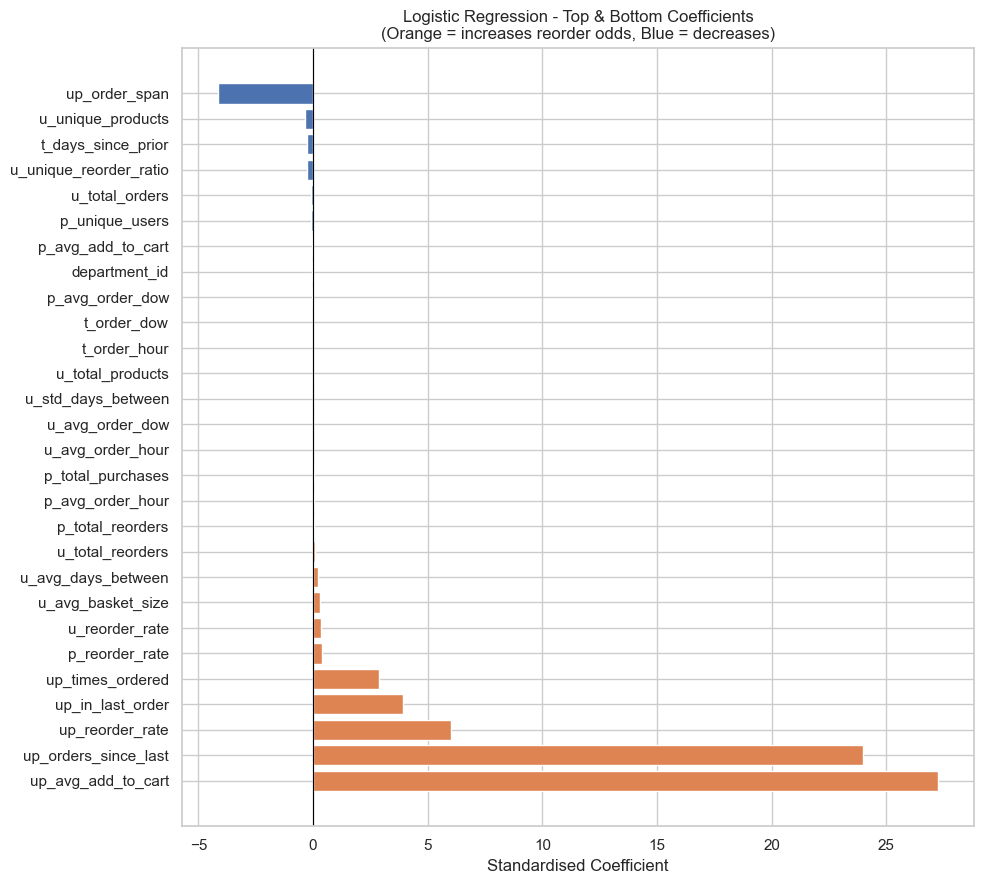

In [15]:
top15   = coef_df.head(15)
bottom15 = coef_df.tail(15)
plot_df  = pd.concat([top15, bottom15]).drop_duplicates()

plt.figure(figsize=(10, 9))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in plot_df['coefficient']]
plt.barh(plot_df['feature'], plot_df['coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Standardised Coefficient')
plt.title('Logistic Regression - Top & Bottom Coefficients\n'
          '(Orange = increases reorder odds, Blue = decreases)')
plt.tight_layout()
plt.show()


## 8. Results Summary

In [16]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results_lr = {
    'Model'              : 'Logistic Regression',
    'ROC-AUC'            : round(roc_auc, 4),
    'PR-AUC (Avg Prec)'  : round(avg_prec, 4),
    'Brier Score'        : round(brier, 4),
    'Best C'             : grid_search.best_params_['C'],
    'Optimal Threshold'  : round(best_threshold, 4),
    'F1 (optimal thresh)': round(f1_score(y_test, y_pred_opt), 4),
    'Precision (opt)'    : round(precision_score(y_test, y_pred_opt), 4),
    'Recall (opt)'       : round(recall_score(y_test, y_pred_opt), 4),
    'Accuracy (opt)'     : round(accuracy_score(y_test, y_pred_opt), 4),
    'F1 (0.50 thresh)'   : round(f1_score(y_test, y_pred_05), 4),
}

print("Logistic Regression Results")
print("-" * 45)
for k, v in results_lr.items():
    print(f"  {k:<25} : {v}")


Logistic Regression Results
---------------------------------------------
  Model                     : Logistic Regression
  ROC-AUC                   : 0.9689
  PR-AUC (Avg Prec)         : 0.9841
  Brier Score               : 0.0472
  Best C                    : 10.0
  Optimal Threshold         : 0.3793
  F1 (optimal thresh)       : 0.952
  Precision (opt)           : 0.9999
  Recall (opt)              : 0.9085
  Accuracy (opt)            : 0.9452
  F1 (0.50 thresh)          : 0.952


## 9. Save Model & Results

In [17]:
save_dir = MODEL_DIR  # '../models' -- defined in Configuration cell
os.makedirs(save_dir, exist_ok=True)

joblib.dump(lr_tuned,  os.path.join(save_dir, 'lr_tuned.pkl'))
joblib.dump(coef_df,   os.path.join(save_dir, 'lr_coef_df.pkl'))

results_df = pd.DataFrame([results_lr])
results_df.to_csv(os.path.join(save_dir, 'lr_results.csv'), index=False)

print(f"Saved to: {os.path.abspath(save_dir)}")
for fname in ['lr_tuned.pkl', 'lr_coef_df.pkl', 'lr_results.csv']:
    fpath = os.path.join(save_dir, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<25} {size:>8.2f} MB")


Saved to: /Users/martinmilon/Documents/DTSC870/models
  lr_tuned.pkl                  0.00 MB
  lr_coef_df.pkl                0.00 MB
  lr_results.csv                0.00 MB


## 10. Key Takeaways & Handoff to Step 5

### Interpreting the results
- **ROC-AUC** is the primary benchmark for LightGBM — record this number.
- **PR-AUC** is particularly informative given the class imbalance; compare it to
  the no-skill baseline of 0.60.
- **Brier Score** penalises confident wrong predictions and will be used to compare
  probability calibration between both models in Step 6.
- **Coefficient magnitudes** reveal which features drive the linear decision boundary.
  If any coefficients are extremely large (>10 in standardised units), this warrants
  investigation before proceeding.

### What LightGBM can add over Logistic Regression
- Non-linear interactions (e.g. combined effect of recency and frequency)
- Native handling of `aisle_id` and `department_id` as unordered categoricals
- Automatic feature selection via split gain — uninformative features are simply not used
- Typically better calibration on tabular data with mixed feature types

### Artefacts saved to `../models/`

| File | Description |
|---|---|
| `lr_tuned.pkl` | Fitted LogisticRegression (best C from grid search) |
| `lr_coef_df.pkl` | Coefficient dataframe with odds ratios |
| `lr_results.csv` | Metrics summary — loaded by Step 6 for side-by-side comparison |
